## METHOD 3

In [1]:
from dataclasses import dataclass
from datetime import date
from typing import List


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA

##### Define the Critique Class

In [2]:
@dataclass
class Critique:
    critique_id: str
    painting_id: str
    critic_name: str
    title: str
    text: str
    published_at: date
    label: int   # 1 = expert critique, 0 = student critique

##### Create Various Critiques

In [3]:
critiques: List[Critique] = [
   Critique(
    critique_id="E1",
    painting_id="P1",
    critic_name="Expert A",
    title="Composition and Structure",
    text="The painting demonstrates strong compositional balance, spatial depth, controlled movement, and a carefully organized visual hierarchy.",
    published_at=date(2021, 5, 12),
    label=1
),

Critique(
    critique_id="E2",
    painting_id="P1",
    critic_name="Expert B",
    title="Color and Light",
    text="The artist uses a restrained color palette, dramatic illumination, and subtle tonal contrast to create emotional tension.",
    published_at=date(2022, 3, 18),
    label=1
),

Critique(
    critique_id="E3",
    painting_id="P1",
    critic_name="Expert C",
    title="Psychological Reading",
    text="The figures and shadows suggest inner conflict, emotional ambiguity, and a psychologically charged interpretation of the scene.",
    published_at=date(2023, 1, 9),
    label=1
),

Critique(
    critique_id="E4",
    painting_id="P1",
    critic_name="Expert D",
    title="Historical Context",
    text="The work reflects the visual language of its historical period, connecting religious symbolism, patronage, and cultural context.",
    published_at=date(2020, 10, 5),
    label=1
),

Critique(
    critique_id="E5",
    painting_id="P1",
    critic_name="Expert E",
    title="Symbol and Story",
    text="The symbolic gestures, placement of figures, and narrative details invite an iconographic reading of the painting.",
    published_at=date(2021, 8, 22),
    label=1
),

Critique(
    critique_id="S1",
    painting_id="P1",
    critic_name="Student 1",
    title="Drama Through Light and Placement",
    text="The painting uses light and shadow to create a serious mood. The placement of the figures makes the scene feel dramatic and meaningful.",
    published_at=date(2024, 2, 12),
    label=0
),
    Critique(
    critique_id="S4",
    painting_id="P1",
    critic_name="Student 4",
    title="Emotional Response",
    text="The dark tones and facial expressions create a feeling of sadness and tension. The shadows make the scene feel emotionally powerful and mysterious.",
    published_at=date(2024, 2, 13),
    label=0
),

Critique(
    critique_id="S5",
    painting_id="P1",
    critic_name="Student 5",
    title="Formal Analysis Attempt",
    text="The composition guides the viewer through the scene using contrast, spatial depth, and careful placement of figures. The lighting reinforces the emotional intensity of the painting.",
    published_at=date(2024, 2, 14),
    label=0
),

Critique(
    critique_id="S6",
    painting_id="P1",
    critic_name="Student 6",
    title="General Impression",
    text="I think the artist wanted to create a dramatic atmosphere. The painting is beautiful and interesting, although some parts are difficult to understand.",
    published_at=date(2024, 2, 15),
    label=0
),

Critique(
    critique_id="S7",
    painting_id="P1",
    critic_name="Student 7",
    title="Symbolic Interpretation",
    text="The arrangement of the figures and the use of shadow may symbolize conflict or isolation. The visual structure suggests a deeper psychological meaning beneath the surface narrative.",
    published_at=date(2024, 2, 16),
    label=0
),
]

## c.__dict__ converts each object into a dictionary containing its fields and values.
df = pd.DataFrame([c.__dict__ for c in critiques])
## print the first row                 
print(df.iloc[0])
## Select only certain columns
df[["critique_id", "critic_name", "title", "label"]]

critique_id                                                    E1
painting_id                                                    P1
critic_name                                              Expert A
title                                   Composition and Structure
text            The painting demonstrates strong compositional...
published_at                                           2021-05-12
label                                                           1
Name: 0, dtype: object


,critique_id,critic_name,title,label
0,E1,Expert A,Composition and Structure,1
1,E2,Expert B,Color and Light,1
2,E3,Expert C,Psychological Reading,1
3,E4,Expert D,Historical Context,1
4,E5,Expert E,Symbol and Story,1
5,S1,Student 1,Drama Through Light and Placement,0
6,S4,Student 4,Emotional Response,0
7,S5,Student 5,Formal Analysis Attempt,0
8,S6,Student 6,General Impression,0
9,S7,Student 7,Symbolic Interpretation,0


##### Use a SentenceTransformer as a Model

In [ ]:
model = SentenceTransformer("all-MiniLM-L6-v2")

##### Convert Critiques into Dense Embeddings

In [6]:
# Each row is now a dense semantic vector. Unlike TF-IDF, the columns
# do not correspond to individual words. 
#They are learned dimensions of meaning

texts = df["text"].tolist()

embeddings = model.encode(
    texts,
    normalize_embeddings=True
)

print("Embedding matrix shape:", embeddings.shape)

Embedding matrix shape: (10, 384)


##### Compute Cosine Similarity Between All Critiques

In [7]:
similarity_matrix = cosine_similarity(embeddings)

sim_df = pd.DataFrame(
    similarity_matrix,
    index=df["critique_id"],
    columns=df["critique_id"]
)

sim_df

critique_id,E1,E2,E3,E4,E5,S1,S4,S5,S6,S7
critique_id,,,,,,,,,,
E1,1.000000,0.487931,0.316903,0.434732,0.657988,0.636423,0.310718,0.728799,0.600954,0.453058
E2,0.487931,1.000000,0.472522,0.405480,0.481810,0.632932,0.626557,0.628976,0.673978,0.434931
E3,0.316903,0.472522,1.000000,0.400989,0.509073,0.588708,0.690849,0.424950,0.453656,0.840050
E4,0.434732,0.405480,0.400989,1.000000,0.640699,0.499155,0.367891,0.492298,0.508177,0.501215
E5,0.657988,0.481810,0.509073,0.640699,1.000000,0.709418,0.367100,0.649376,0.628893,0.561065
S1,0.636423,0.632932,0.588708,0.499155,0.709418,1.000000,0.632537,0.783417,0.720839,0.644732
S4,0.310718,0.626557,0.690849,0.367891,0.367100,0.632537,1.000000,0.501259,0.481079,0.612212
S5,0.728799,0.628976,0.424950,0.492298,0.649376,0.783417,0.501259,1.000000,0.704973,0.464725
S6,0.600954,0.673978,0.453656,0.508177,0.628893,0.720839,0.481079,0.704973,1.000000,0.455928


##### Compare the Student Critiques With Expert Critiques¶


In [8]:
# Actual expert-written critiques
expert_indices = df[
    df["critic_name"].str.contains("Expert", case=False, na=False)
].index

# Student-written critiques
student_indices = df[
    df["critic_name"].str.contains("Student", case=False, na=False)
].index

# Embeddings for expert critiques
expert_embeddings = embeddings[expert_indices]

# Store rankings for all students
all_rankings = []

for student_idx in student_indices:

    # Get embedding for one student critique
    student_embedding = embeddings[student_idx].reshape(1, -1)

    # Compute cosine similarity against all expert critiques
    student_to_experts = cosine_similarity(
        student_embedding,
        expert_embeddings
    ).flatten()

    # Build ranking dataframe
    ranking_df = df.loc[
        expert_indices,
        ["critique_id", "critic_name", "title"]
    ].copy()

    # Add student information
    ranking_df["student_id"] = df.loc[student_idx, "critique_id"]
    ranking_df["student_title"] = df.loc[student_idx, "title"]
    ranking_df["student_label"] = df.loc[student_idx, "label"]

    # Add semantic similarity scores
    ranking_df["semantic_similarity"] = student_to_experts

    # Sort by similarity
    ranking_df = ranking_df.sort_values(
        by="semantic_similarity",
        ascending=False
    )

    # Store results
    all_rankings.append(ranking_df)

# Combine all rankings into one dataframe
student_expert_rankings = pd.concat(all_rankings)

# Display results
student_expert_rankings = student_expert_rankings[
    [
        "student_id",
        "student_title",
        "student_label",
        "critique_id",
        "critic_name",
        "title",
        "semantic_similarity"
    ]
]

student_expert_rankings

,student_id,student_title,student_label,critique_id,critic_name,title,semantic_similarity
4,S1,Drama Through Light and Placement,0,E5,Expert E,Symbol and Story,0.709418
0,S1,Drama Through Light and Placement,0,E1,Expert A,Composition and Structure,0.636424
1,S1,Drama Through Light and Placement,0,E2,Expert B,Color and Light,0.632932
2,S1,Drama Through Light and Placement,0,E3,Expert C,Psychological Reading,0.588708
3,S1,Drama Through Light and Placement,0,E4,Expert D,Historical Context,0.499154
2,S4,Emotional Response,0,E3,Expert C,Psychological Reading,0.690849
1,S4,Emotional Response,0,E2,Expert B,Color and Light,0.626557
3,S4,Emotional Response,0,E4,Expert D,Historical Context,0.367891
4,S4,Emotional Response,0,E5,Expert E,Symbol and Story,0.367100
0,S4,Emotional Response,0,E1,Expert A,Composition and Structure,0.310718


##### Compute the mean expert centroid¶

In [9]:
expert_df = df[df["label"] == 1].copy()

# Get embeddings for expert critiques
expert_embeddings = embeddings[expert_df.index]

# Compute centroid (mean embedding)
expert_centroid = expert_embeddings.mean(axis=0)

# Normalize centroid
expert_centroid = expert_centroid / np.linalg.norm(expert_centroid)

print("Expert centroid shape:", expert_centroid.shape)

Expert centroid shape: (384,)


##### Compute Expert-Likeness Score

In [10]:
# Select all critiques written by students
student_df = df[
    df["critic_name"].str.contains("Student", case=False, na=False)
]

for idx in student_df.index:

    # Get embedding for one student critique
    student_embedding = embeddings[idx].reshape(1, -1)
    ##Note: a single embedding vector has shape (384,)
    ## after reshape(1, -1) it becomes (1, 384)

    # Compute cosine similarity with expert centroid
    similarity = cosine_similarity(
        student_embedding,
        expert_centroid.reshape(1, -1)
    )[0][0]

    print(
        df.loc[idx, "critique_id"],
        "-",
        df.loc[idx, "title"],
        "| Expert-Likeness Score:",
        round(similarity, 3)
    )

S1 - Drama Through Light and Placement | Expert-Likeness Score: 0.802
S4 - Emotional Response | Expert-Likeness Score: 0.618
S5 - Formal Analysis Attempt | Expert-Likeness Score: 0.765
S6 - General Impression | Expert-Likeness Score: 0.75
S7 - Symbolic Interpretation | Expert-Likeness Score: 0.73


##### Compute PCA

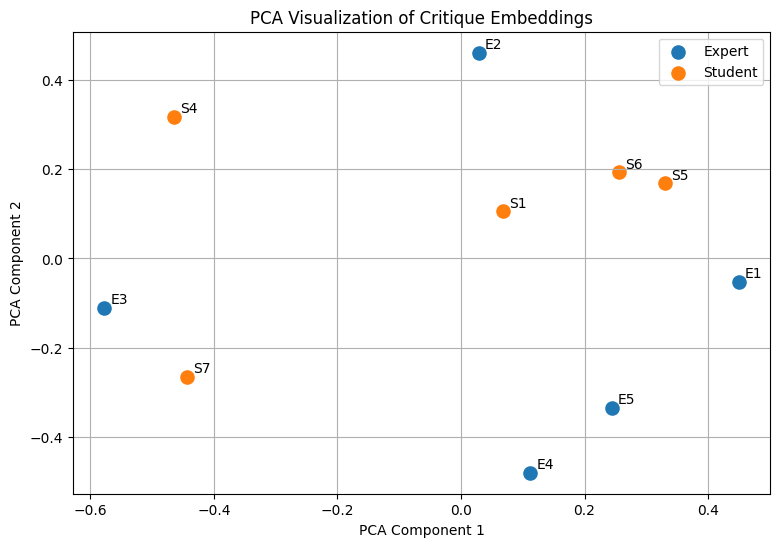

In [11]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
coords = pca.fit_transform(embeddings)

plot_df = df.copy()
plot_df["x"] = coords[:, 0]
plot_df["y"] = coords[:, 1]

plt.figure(figsize=(9, 6))

for label_value, marker_name in [(1, "Expert"), (0, "Student")]:
    subset = plot_df[plot_df["label"] == label_value]
    plt.scatter(
        subset["x"],
        subset["y"],
        label=marker_name,
        s=90
    )

for _, row in plot_df.iterrows():
    plt.text(
        row["x"] + 0.01,
        row["y"] + 0.01,
        row["critique_id"],
        fontsize=10
    )

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("PCA Visualization of Critique Embeddings")
plt.legend()
plt.grid(True)
plt.show()